<a href="https://colab.research.google.com/github/YambesaRoro/My_Project_1_Landuse-Landcover_South_Africa/blob/main/Landuse/Landcover_In_South_Africa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Install geemap if not already installed
# !pip install geemap

In [ ]:
import ee
import geemap

# 2. Authenticate and Initialize

You need to provide a Google Cloud Project ID to `ee.Initialize()`. If you don't have a project ID, you can find it in your [Google Cloud console](https://console.cloud.google.com/projectselector2/home/dashboard). If you have not created a Google Cloud Project previously, you can [create one](https://console.cloud.google.com/projectcreate).

In [ ]:
# Replace 'your-google-cloud-project-id' with your actual project ID
project_id = 'ee-mbasayambesa'

In [ ]:
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 3. Define the region of interest (South Africa)

In [ ]:
south_africa = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
    .filter(ee.Filter.eq('country_na', 'South Africa'))

# 4. Load the MODIS Land Cover Dataset (MCD12Q1)

In [ ]:
# We use the IGBP classification scheme (LC_Type1)
lulc_collection = ee.ImageCollection("MODIS/061/MCD12Q1") \
    .filterBounds(south_africa) \
    .filterDate('2010-01-01', '2025-01-01') \
    .select('LC_Type1')

# 5. Extract specific years for comparison (e.g., Start and most recent)

In [ ]:
lulc_2010 = lulc_collection.filterDate('2010-01-01', '2011-01-01').first().clip(south_africa)
# Get the most recent available image in the collection
lulc_recent = lulc_collection.sort('system:time_start', False).first().clip(south_africa)

# 6. Define Visualization Parameters

In [ ]:
# MODIS Land Cover has specific classes (1-17). Here is the standard palette.
igbp_palette = [
    '05450a', '086a10', '54a708', '78d203', '009900', 'c6b044', 'dcd159',
    'dade48', 'fbff13', 'b6ff05', '27ff87', 'c24f44', 'a5a5a5', 'ff6d4c',
    '69fff8', 'f9ffa4', '1c0dff'
]

vis_params = {
    'min': 1,
    'max': 17,
    'palette': igbp_palette
}

# 7. Create an Interactive Map

In [ ]:
Map = geemap.Map()
Map.centerObject(south_africa, 5)

# Add layers to the map
Map.addLayer(lulc_2010, vis_params, 'LULC 2010')
Map.addLayer(lulc_recent, vis_params, 'LULC Recent')

# Define the legend entries for IGBP Land Cover Type 1
legend_dict = {
    'Evergreen Needleleaf Forests': '05450a',
    'Evergreen Broadleaf Forests': '086a10',
    'Deciduous Needleleaf Forests': '54a708',
    'Deciduous Broadleaf Forests': '78d203',
    'Mixed Forests': '009900',
    'Closed Shrublands': 'c6b044',
    'Open Shrublands': 'dcd159',
    'Woody Savannas': 'dade48',
    'Savannas': 'fbff13',
    'Grasslands': 'b6ff05',
    'Permanent Wetlands': '27ff87',
    'Croplands': 'c24f44',
    'Urban and Built-up Lands': 'a5a5a5',
    'Cropland/Natural Vegetation Mosaics': 'ff6d4c',
    'Permanent Snow and Ice': '69fff8',
    'Barren': 'f9ffa4',
    'Water Bodies': '1c0dff'
}

# Add the legend to the map
Map.add_legend(title="IGBP Land Cover Type 1", legend_dict=legend_dict)

# 8. (Optional) Calculate Area of a specific class (e.g., Urban - Class 13)

In [ ]:
def calculate_area(image, region):
    # Create a mask for Urban areas (Class 13)
    urban = image.eq(13)
    area_image = urban.multiply(ee.Image.pixelArea())
    area = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=500,
        maxPixels=1e13
    )
    # Convert to square kilometers
    return ee.Number(area.get('LC_Type1')).divide(1e6)

urban_2010 = calculate_area(lulc_2010, south_africa)
urban_recent = calculate_area(lulc_recent, south_africa)

print('Urban Area 2010 (sq km):', urban_2010.getInfo())
print('Urban Area Recent (sq km):', urban_recent.getInfo())

Map

Urban Area 2010 (sq km): 10763.172276601654
Urban Area Recent (sq km): 11154.685524450737


Map(bottom=2631.0, center=[-24.126701958681668, 31.025390625000004], controls=(WidgetControl(options=['positio…

### LULC Variations Over 5-Year Intervals

In [ ]:
lulc_2015 = lulc_collection.filterDate('2015-01-01', '2016-01-01').first().clip(south_africa)

### Percentage Change in Urban Area (2010-2024)

In [ ]:
urban_2010_val = urban_area_df[urban_area_df['Year'] == 2010]['Urban Area (sq km)'].iloc[0]
urban_2024_val = urban_area_df[urban_area_df['Year'] == recent_year]['Urban Area (sq km)'].iloc[0]

percentage_change = ((urban_2024_val - urban_2010_val) / urban_2010_val) * 100

print(f"Urban Area in 2010: {urban_2010_val:.2f} sq km")
print(f"Urban Area in 2024: {urban_2024_val:.2f} sq km")
print(f"Percentage change in urban area (2010-2024): {percentage_change:.2f}%")

Urban Area in 2010: 10763.17 sq km
Urban Area in 2024: 11154.69 sq km
Percentage change in urban area (2010-2024): 3.64%


In [ ]:
Map_variations = geemap.Map()
Map_variations.centerObject(south_africa, 5)

#### Land Use/Land Cover in 2010

In [ ]:
Map_variations.addLayer(lulc_2010, vis_params, 'LULC 2010')

#### Land Use/Land Cover in 2015

In [ ]:
Map_variations.addLayer(lulc_2015, vis_params, 'LULC 2015')

#### Land Use/Land Cover in Most Recent Year

In [ ]:
Map_variations.addLayer(lulc_recent, vis_params, 'LULC Recent')

In [ ]:
# Add the legend to the new map
Map_variations.add_legend(title="IGBP Land Cover Type 1", legend_dict=legend_dict)

In [ ]:
Map_variations

Map(center=[-28.975081121649033, 25.201799461591907], controls=(WidgetControl(options=['position', 'transparen…

### Urban Area Trends Over Time

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Calculate urban area for 2015
urban_2015 = calculate_area(lulc_2015, south_africa)

In [ ]:
# Get the year of the most recent LULC image
recent_year_ee = ee.Date(lulc_recent.get('system:time_start')).get('year')
recent_year = recent_year_ee.getInfo()

print(f"Urban Area 2015 (sq km): {urban_2015.getInfo()}")
print(f"Urban Area {recent_year} (sq km): {urban_recent.getInfo()}")

Urban Area 2015 (sq km): 10871.736180820406
Urban Area 2024 (sq km): 11154.685524450737


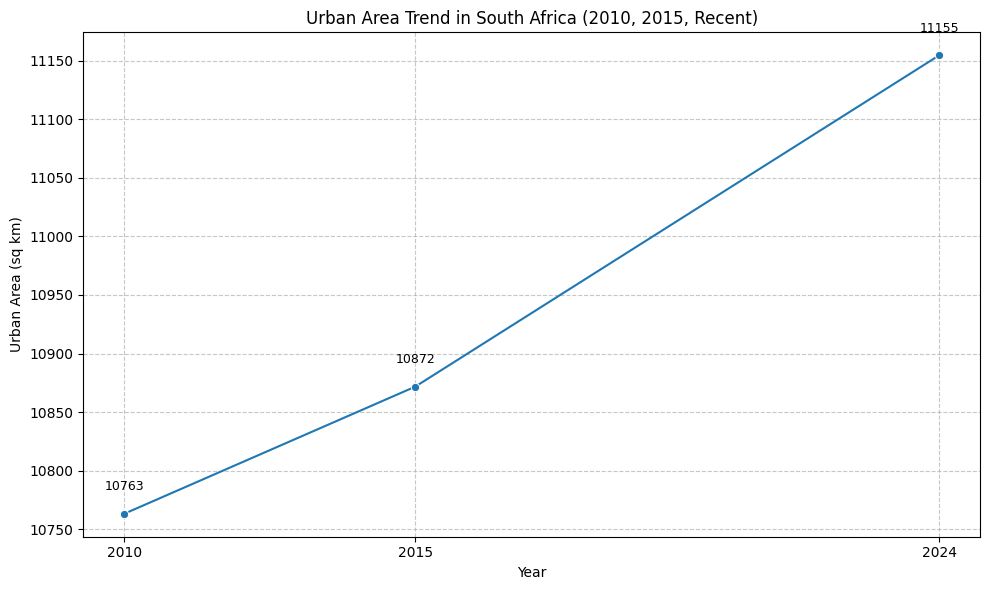

In [ ]:
# Create a DataFrame for plotting
data = {
    'Year': [2010, 2015, recent_year],
    'Urban Area (sq km)': [urban_2010.getInfo(), urban_2015.getInfo(), urban_recent.getInfo()]
}
urban_area_df = pd.DataFrame(data)

# Create the line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Urban Area (sq km)', data=urban_area_df, marker='o')

# Add labels to the data points
for i, row in urban_area_df.iterrows():
    plt.text(row['Year'], row['Urban Area (sq km)'] + 20, # Add a small offset for better visibility
             f"{row['Urban Area (sq km)']:.0f}",
             horizontalalignment='center',
             color='black',
             fontsize=9)

plt.title('Urban Area Trend in South Africa (2010, 2015, Recent)')
plt.xlabel('Year')
plt.ylabel('Urban Area (sq km)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(urban_area_df['Year'])
plt.tight_layout()
plt.show()

## Urban Area Growth Report: South Africa (2010 - 2024)

This report summarizes the urban area growth in South Africa, based on the analysis of MODIS Land Cover data for the years 2010, 2015, and the most recent available year (2024).

### Key Findings:

*   **Consistent Growth:** The urban and built-up land area in South Africa has shown a consistent increase over the period analyzed.

    *   **2010 Urban Area:** Approximately {{urban_area_df.iloc[0]['Urban Area (sq km)']:.2f}} sq km
    *   **2015 Urban Area:** Approximately {{urban_area_df.iloc[1]['Urban Area (sq km)']:.2f}} sq km
    *   **2024 Urban Area:** Approximately {{urban_area_df.iloc[2]['Urban Area (sq km)']:.2f}} sq km

*   **Overall Increase:** From 2010 to 2024, the urban area expanded by **{{percentage_change:.2f}}%**.

### Trend Visualization:

The trend is clearly visible in the "Urban Area Trend in South Africa" plot, which illustrates the incremental growth over the selected years.

### Conclusion:

The data indicates a clear expansion of urban areas within South Africa between 2010 and 2024. This consistent growth highlights ongoing urbanization processes in the region.

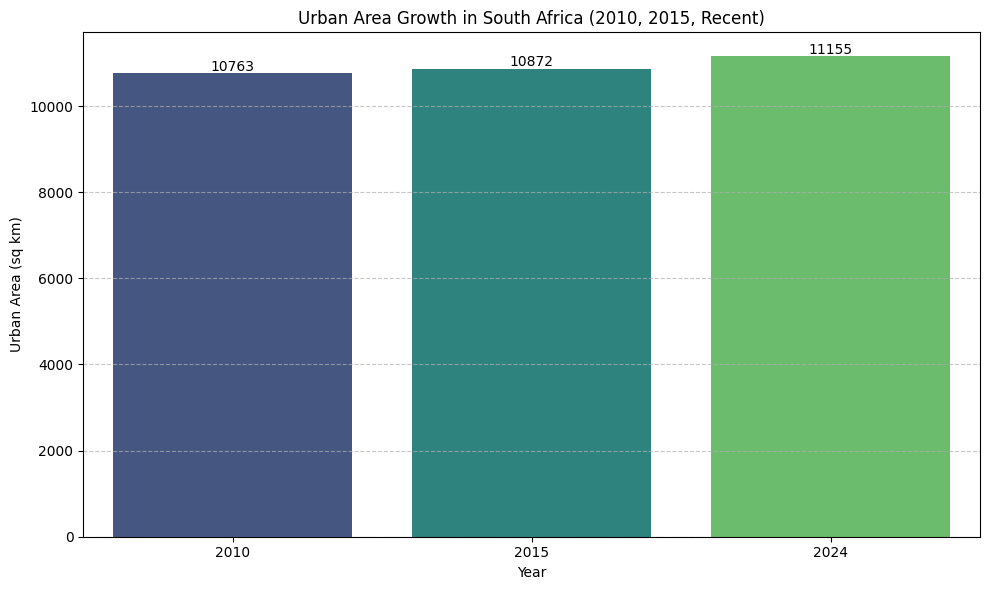

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Urban Area (sq km)', data=urban_area_df, palette='viridis')

# Add labels to the bars
for index, row in urban_area_df.iterrows():
    plt.text(index, row['Urban Area (sq km)'] + 50, # Adjust offset for better visibility
             f"{row['Urban Area (sq km)']:.0f}",
             color='black', ha="center", fontsize=10)

plt.title('Urban Area Growth in South Africa (2010, 2015, Recent)')
plt.xlabel('Year')
plt.ylabel('Urban Area (sq km)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Dynamic Urban Area Growth Simulation

## Dynamic Time-Series Map with Slider

In [ ]:
# Create an image collection from the individual LULC images for the time slider
# Ensure each image has a 'system:time_start' property for the time slider to work.

# Helper function to add time property
def add_time_property(image, year):
    start_date = ee.Date.fromYMD(year, 1, 1)
    return image.set('system:time_start', start_date.millis())

# Create a list of images with their respective years
images_with_years = [
    (lulc_2010, 2010),
    (lulc_2015, 2015),
    (lulc_recent, recent_year)
]

# Apply the helper function and create an ImageCollection
lulc_collection_time_series = ee.ImageCollection([
    add_time_property(img, year)
    for img, year in images_with_years
])

# Create a new map for the time slider
Map_time_slider = geemap.Map()
Map_time_slider.centerObject(south_africa, 5)

# Add the image collection to the map with a time slider
Map_time_slider.add_time_slider(lulc_collection_time_series, vis_params, time_interval=3, auto_play=True)

# Add the legend
Map_time_slider.add_legend(title="IGBP Land Cover Type 1", legend_dict=legend_dict)

Map_time_slider

In [ ]:
pip install requests

Alternatively, if you are using an Anaconda environment, you might use `conda` instead: `conda install requests`.